In [51]:
#Import Libraries
#---------------------------------------------------------------------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [52]:
#Check working Directory
print("Current directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current directory:
/Users/thaveeshaweerakkody/Desktop/Final Year Original/2 sem/Final year Project/Breast_Cancer_WebApplication/backend/ai

Files here:
['.DS_Store', 'saved_model', 'dataset', '.ipynb_checkpoints', 'model_training.ipynb']


In [53]:
#Explore Dataset Folder
dataset_path = "dataset"
print(os.listdir(dataset_path))

['.DS_Store', 'malignant', 'benign', 'normal']


In [54]:
#Load image and Mask safely
image_path = "dataset/benign/benign (1).png"
mask_path = "dataset/benign/benign (1)_mask.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print("Image loaded:", image is not None)
print("Mask loaded:", mask is not None)

Image loaded: True
Mask loaded: True


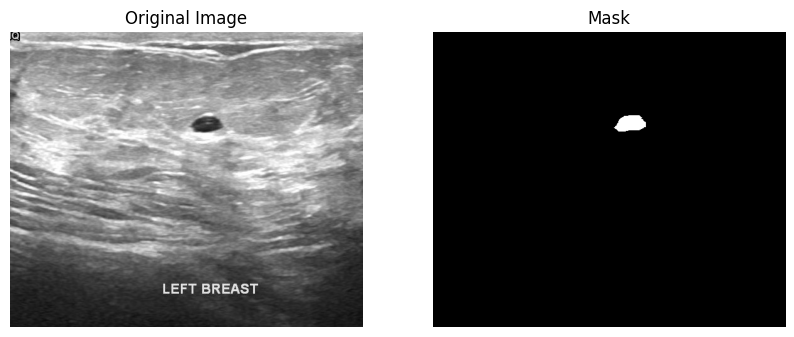

In [55]:
#Visualise original Image+Mask
#Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [56]:
#Resize Image & Mask
IMG_SIZE = 224

image_resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

In [57]:
#Apply Mask
#Convert mask to 0-1 range
mask_binary = mask_resized/ 255.0 #convert to 0-1

#Apply mask to image
masked_image = image_resized * mask_binary[..., np.newaxis]

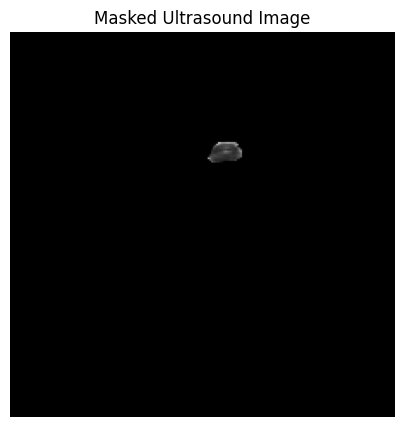

In [58]:
#Visualising masked image
plt.figure(figsize=(5,5))
plt.imshow(masked_image.astype(np.uint8))
plt.title("Masked Ultrasound Image")
plt.axis("off")
plt.show()

In [59]:
#Preparing the full dataset for training


#Dataset Loading
#Define constants and labelsis
IMG_SIZE = 224

labels = {
        "normal": 0,
        "benign": 1,
        "malignant": 2
}

In [60]:
#Create empty lists

x = []  #images
y = []  #lables

In [61]:
#Loop through each class folder
for class_name in labels:
    #Build full path to class folder
    class_path = os.path.join(dataset_path, class_name)
    print(f"Processing folder: {class_name}")

Processing folder: normal
Processing folder: benign
Processing folder: malignant


In [62]:
#Load images and masks
for file in os.listdir(class_path):

    #skip mask files
    if "_mask" in file:
        continue

    image_path = os.path.join(class_path, file)
    mask_path = image_path.replace(".png", "_mask.png")

    image = cv2.imread(image_path)
    if image is None:
        continue

In [63]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_resized = cv2.resize(image_rgb, (IMG_SIZE,IMG_SIZE))

if os.path.exists(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask_binary = mask_resized/255.0
    image_resized = image_resized * mask_binary[..., np.newaxis]

In [64]:
x.append(image_resized)
y.append(labels[class_name])

In [65]:
#Converting lists to Numpy arrays
x = np.array(x, dtype=np.float32)
y =np.array(y)

print("Dataset shape:", x.shape)
print("Labels shape:", y.shape)

Dataset shape: (1, 224, 224, 3)
Labels shape: (1,)


In [47]:
#Phase 6-Create Training Data (Images and Labels)
#------------------------------------------------------------------------------------
#Define class labels
labels = ["benign", "malignant", "normal"]

#Create empty lists to store data
x = [] #imges
y = [] #labels

In [48]:
#Loop through Dataset Folders
dataset_path = "dataset"

for class_index, class_name in enumerate(labels):
    class_path = os.path.join(dataset_path, class_name)
    print(f"\nProcessing folder: {class_name}")


Processing folder: benign

Processing folder: malignant

Processing folder: normal


In [75]:
#Read Images Safely
for file in os.listdir(class_path):
    if file.endswith(".png") and "_mask" not in file:
        image_path = os.path.join(class_path, file)
        mask_path = image_path.replace(".png", "_mask.png")
        #Load Image and amsk
        image = cv2.imread(image_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            image = cv2.resize(image, (224, 224))
            mask = cv2.resize(mask, (224, 224))
            
            mask = mask / 255.0 #convert to 0-1
            masked_image = image * [..., np.newaxis]

            #Store Data
            x.append(masked_image)
            y.append(class_index)

In [76]:
#Convert to Numpy Arrays
x = np.array(x)
y = np.array(y)

print("Daraset loaded!")
print("X shape:", x.shape)
print("y shape:", y.shape)

Daraset loaded!
X shape: (1, 224, 224, 3)
y shape: (1,)
